# 05 Multi Statement Cross Examiner

**Project:** Insurance Fraud Detection Assistant

**Notebook:** `05-multi-statement-cross-examiner.ipynb`

In [2]:
# ==========================================
# Notebook 05
# Multi Statement Cross Examiner
# ==========================================

import pandas as pd
import numpy as np

from sentence_transformers import SentenceTransformer

from sklearn.metrics.pairwise import cosine_similarity

import matplotlib.pyplot as plt
import seaborn as sns

d:\Books\projects-nlp-transformers-learning\.projectnlps\Lib\site-packages\sentence_transformers\cross_encoder\CrossEncoder.py:11: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm, trange


In [3]:
claims_df = pd.read_csv("../data/insurance_claims.csv")

In [4]:
claims_df.head()

,claim_id,claimant_name,vehicle_vin,mechanic_shop,clinic_name,lawyer,claimant_statement,police_report,adjuster_notes,medical_bill,fraud_label
0,CLM001,Wendy Holland,FqH15433919443,Rapid Auto Repair,Care First Clinic,Smith & Associates,A vehicle rear-ended me while I was waiting at...,Witnesses confirmed another driver caused the ...,Section international though many movement.,5072,0
1,CLM002,Douglas Lara,acF49501195178,Rapid Auto Repair,Wellness Recovery Center,Anderson Legal,The vehicle changed lanes unexpectedly and hit...,Police observed damage consistent with reporte...,Budget Mrs part spend middle threat smile incr...,1541,0
2,CLM003,Chloe Murphy,xeQ24677572737,Rapid Auto Repair,Care First Clinic,Justice Partners,I was stopped at a red light when another vehi...,Accident report indicates claimant followed tr...,Similar never box line.,20226,1
3,CLM004,Jodi Reynolds MD,sPL40843321198,Rapid Auto Repair,Wellness Recovery Center,Justice Partners,The vehicle changed lanes unexpectedly and hit...,Police observed damage consistent with reporte...,Section season nor political bank.,7723,0
4,CLM005,Elizabeth Patel,mmr35740163797,Prime Vehicle Repair,Wellness Recovery Center,Smith & Associates,I was driving through an intersection when ano...,Witnesses confirmed another driver caused the ...,Kind compare across audience society.,23376,0


In [5]:
embedding_model = SentenceTransformer("sentence-transformers/all-mpnet-base-v2")

In [6]:
def calculate_similarity(text_a, text_b, model):

    emb_a = model.encode(str(text_a))

    emb_b = model.encode(str(text_b))

    score = cosine_similarity(emb_a.reshape(1, -1), emb_b.reshape(1, -1))[0][0]

    return float(score)

In [ ]:
def build_discrepancy_vector(claimant_statement, police_report, adjuster_notes, model):
    claim_police = calculate_similarity(claimant_statement, police_report, model)

    claim_adjuster = calculate_similarity(claimant_statement, adjuster_notes, model)

    police_adjuster = calculate_similarity(police_report, adjuster_notes, model)

    return {
        "claim_police": claim_police,
        "claim_adjuster": claim_adjuster,
        "police_adjuster": police_adjuster,
    }

In [13]:
example = claims_df.iloc[0]

In [14]:
vector = build_discrepancy_vector(
    example["claimant_statement"],
    example["police_report"],
    example["adjuster_notes"],
    embedding_model,
)

vector

{'claim_police': 0.46486085653305054,
 'claim_adjuster': -0.005295204930007458,
 'police_adjuster': -0.01855395920574665}

In [ ]:
def fraud_risk_score(vector):
    avg_similarity = np.mean(
        [vector["claim_police"], vector["claim_adjuster"], vector["police_adjuster"]]
    )
    return round(1 - avg_similarity, 4)

In [20]:
fraud_risk_score(vector)

0.853

In [21]:
investigation_results = []

In [23]:
for _, row in claims_df.iterrows():
    vector = build_discrepancy_vector(
        row["claimant_statement"],
        row["police_report"],
        row["adjuster_notes"],
        embedding_model,
    )

In [ ]:
risk_score = fraud_risk_score(vector)

In [ ]:
investigation_results.append(
    {
        "claim_id": row["claim_id"],
        "claim_police": vector["claim_police"],
        "claim_adjuster": vector["claim_adjuster"],
        "police_adjuster": vector["police_adjuster"],
        "fraud_risk_score": risk_score,
        "fraud_label": row["fraud_label"],
    }
)

In [28]:
results_df = pd.DataFrame(investigation_results)

In [29]:
results_df.head()

,claim_id,claim_police,claim_adjuster,police_adjuster,fraud_risk_score,fraud_label
0,CLM015,0.567865,-0.016574,0.023531,0.8084,0
1,CLM015,0.567865,-0.016574,0.023531,0.8084,0


In [30]:
results_df.sort_values(by="fraud_risk_score", ascending=False).head()

,claim_id,claim_police,claim_adjuster,police_adjuster,fraud_risk_score,fraud_label
0,CLM015,0.567865,-0.016574,0.023531,0.8084,0
1,CLM015,0.567865,-0.016574,0.023531,0.8084,0


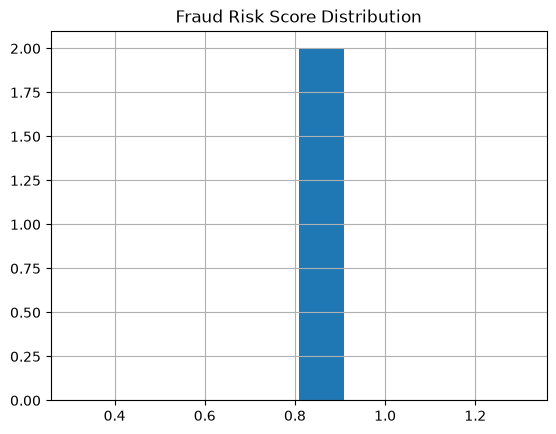

In [31]:
results_df["fraud_risk_score"].hist(bins=10)

plt.title("Fraud Risk Score Distribution")

plt.show()

In [32]:
similarity_columns = ["claim_police", "claim_adjuster", "police_adjuster"]

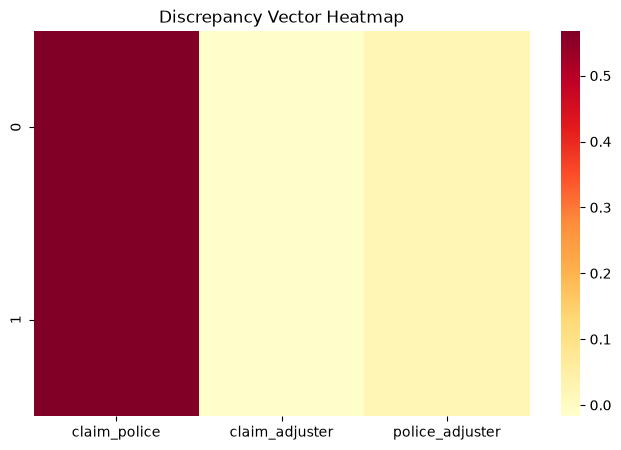

In [33]:
plt.figure(figsize=(8, 5))

sns.heatmap(results_df[similarity_columns], cmap="YlOrRd")

plt.title("Discrepancy Vector Heatmap")

plt.show()

In [34]:
def risk_category(score):

    if score >= 0.50:
        return "High"

    elif score >= 0.30:
        return "Medium"

    return "Low"

In [35]:
results_df["risk_level"] = results_df["fraud_risk_score"].apply(risk_category)

In [36]:
results_df[["claim_id", "fraud_risk_score", "risk_level"]].head()

,claim_id,fraud_risk_score,risk_level
0,CLM015,0.8084,High
1,CLM015,0.8084,High


In [37]:
results_df["risk_level"].value_counts()

risk_level
High    2
Name: count, dtype: int64

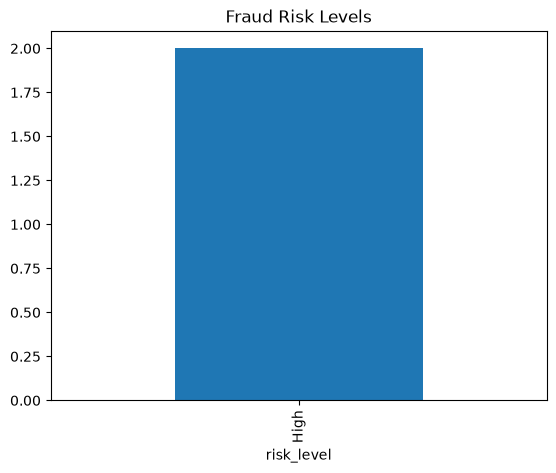

In [38]:
results_df["risk_level"].value_counts().plot(kind="bar")

plt.title("Fraud Risk Levels")

plt.show()

In [39]:
results_df.groupby("fraud_label")["fraud_risk_score"].mean()

fraud_label
0    0.8084
Name: fraud_risk_score, dtype: float64

In [40]:
results_df[
    [
        "claim_police",
        "claim_adjuster",
        "police_adjuster",
        "fraud_risk_score",
        "fraud_label",
    ]
].corr()

,claim_police,claim_adjuster,police_adjuster,fraud_risk_score,fraud_label
claim_police,NaN,NaN,NaN,NaN,NaN
claim_adjuster,NaN,NaN,NaN,NaN,NaN
police_adjuster,NaN,NaN,NaN,NaN,NaN
fraud_risk_score,NaN,NaN,NaN,NaN,NaN
fraud_label,NaN,NaN,NaN,NaN,NaN


In [41]:
high_risk_claims = results_df[results_df["risk_level"] == "High"]

In [42]:
high_risk_claims

,claim_id,claim_police,claim_adjuster,police_adjuster,fraud_risk_score,fraud_label,risk_level
0,CLM015,0.567865,-0.016574,0.023531,0.8084,0,High
1,CLM015,0.567865,-0.016574,0.023531,0.8084,0,High


In [43]:
claim_id = high_risk_claims.iloc[0]["claim_id"]

In [44]:
claim = claims_df[claims_df["claim_id"] == claim_id]

In [45]:
print("CLAIMANT:")

print(claim["claimant_statement"].values[0])

print("\n")

CLAIMANT:
I was driving through an intersection when another vehicle struck my car.




In [46]:
print("POLICE:")

print(claim["police_report"].values[0])

print("\n")

POLICE:
Witnesses confirmed another driver caused the accident.




In [47]:
print("ADJUSTER:")

print(claim["adjuster_notes"].values[0])

ADJUSTER:
They full enjoy property look give.


In [48]:
results_df.to_csv("../data/multi_statement_analysis.csv", index=False)

In [49]:
high_risk_claims.to_csv("../data/high_risk_claim_queue.csv", index=False)